In [1]:
import ast
from matplotlib import pyplot as plt
import pandas as pd
df = pd.read_csv(r'C:\Users\GEORGE TECHNOLOGY EN\Documents\data_jobs.csv')

df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])


In [2]:
df['job_skills']= df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

df = df[df['job_title_short'] == 'Data Analyst']

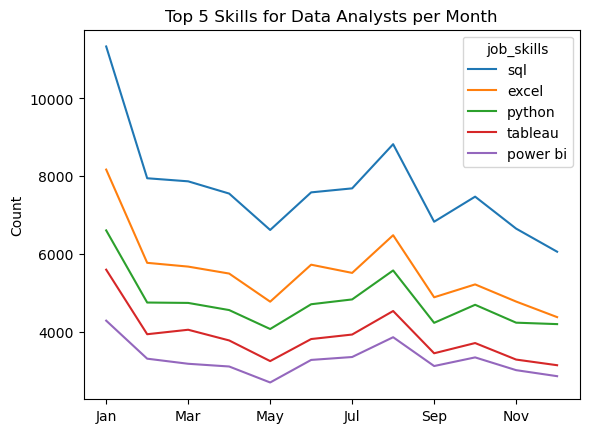

In [3]:
df_DA = df[df['job_title_short'] == 'Data Analyst'].copy()
# create a new column for month number
df_DA['job_posted_month_no'] = df_DA['job_posted_date'].dt.month

# Explode the job_skills column and pivot
df_DA_explode= df_DA.explode('job_skills')
df_DA_pivot = df_DA_explode.pivot_table(index='job_posted_month_no', columns='job_skills',  aggfunc='size', fill_value=0)

# sort the skills by count
df_DA_pivot.loc['Total'] = df_DA_pivot.sum()
df_DA_pivot = df_DA_pivot[df_DA_pivot.loc['Total'].sort_values(ascending=False).index]
df_DA_pivot = df_DA_pivot.drop('Total')

# Use month names for plotting
df_DA_pivot = df_DA_pivot.reset_index()
df_DA_pivot['job_posted_month'] = df_DA_pivot['job_posted_month_no'].apply(lambda x: pd.to_datetime(x, format='%m').strftime('%b'))
df_DA_pivot = df_DA_pivot.set_index('job_posted_month')
df_DA_pivot = df_DA_pivot.drop(columns='job_posted_month_no')

# Get the top 5 skills
df_DA_pivot.iloc[:, :5].plot(kind='line')

plt.title('Top 5 Skills for Data Analysts per Month')
plt.ylabel('Count')
plt.xlabel('')
plt.show()

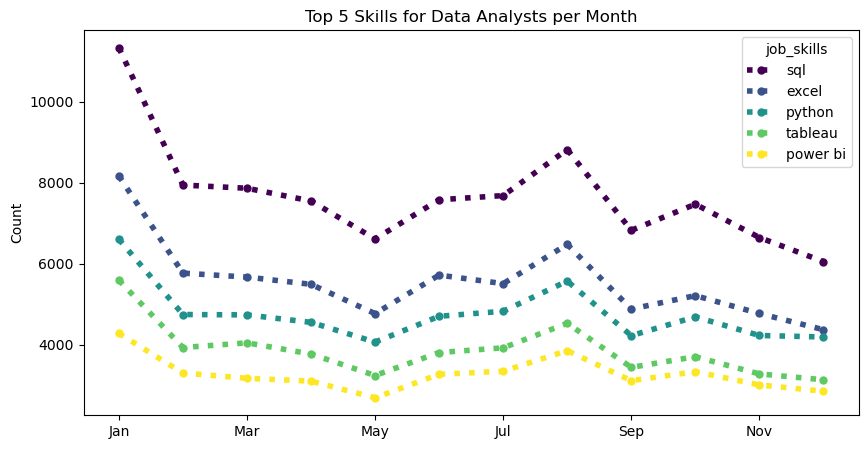

In [12]:
df_DA_pivot.iloc[:, :5].plot(
    kind='line',
    linewidth=4,
    linestyle=':', # options for linestyle '-', '-,', ':'
    colormap='viridis',
    marker='o', # options 'o', 'x', '*', 's', ',', '1', '2', '3' 
    markersize=5,
    figsize=(10,5)
    )
plt.title('Top 5 Skills for Data Analysts per Month')
plt.ylabel('Count')
plt.xlabel('')
plt.show()

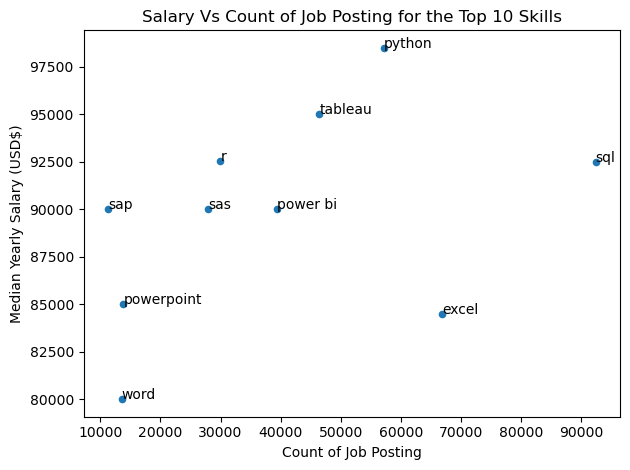

In [ ]:
df = df[df['job_title_short'] == 'Data Analyst']
df_expoled = df.explode('job_skills')
skill_stats = df_expoled.groupby('job_skills').agg(
    skill_count=('job_skills','count'),
    median_salary=('salary_year_avg', 'median')
)

skill_stats = skill_stats.sort_values(by='skill_count',ascending=False).head(20)

skill_stats.plot(kind='scatter',x= 'skill_count',y='median_salary')
plt.title('Salary Vs Count of Job Posting for the Top 10 Skills')
plt.ylabel('Median Yearly Salary (USD$)')
plt.xlabel('Count of Job Posting')
plt.tight_layout()

for i, txt in enumerate(skill_stats.index):
    plt.text(skill_stats['skill_count'].iloc[i], skill_stats['median_salary'].iloc[i], txt)
 
plt.show()

In [17]:
! pip install adjustText

Defaulting to user installation because normal site-packages is not writeable


In [37]:
# in other to not have overlaps on a plot that has to many values the method to use tis (adjust text)
from adjustText import adjust_text

In [33]:
skill_stats = df_expoled.groupby('job_skills').agg(
    skill_count=('job_skills','count'),
    median_salary=('salary_year_avg', 'median'))

skill_stats

,skill_count,median_salary
job_skills,,
airflow,2002,111175.0
airtable,88,90000.0
alteryx,4570,105000.0
angular,376,109101.0
angular.js,2,NaN
...,...,...
wrike,39,75000.0
wsl,16,NaN
xamarin,2,NaN


In [35]:

skill_stat = skill_stats.sort_values(by='skill_count',ascending=False).head(20)

skill_stat

,skill_count,median_salary
job_skills,,
sql,92428,92500.000000
excel,66860,84479.000000
python,57190,98500.000000
tableau,46455,95000.000000
power bi,39380,90000.000000
r,29996,92527.500000
sas,27998,90000.000000
powerpoint,13822,85000.000000
word,13562,80000.000000


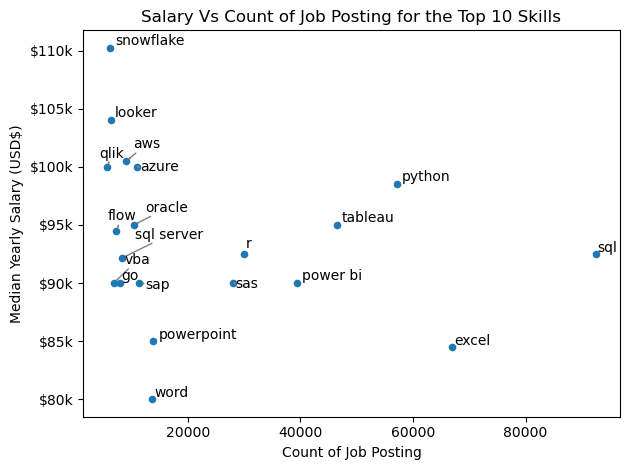

In [45]:

skill_stat.plot(kind='scatter',x= 'skill_count',y='median_salary')
texts = []
for i, txt in enumerate(skill_stat.index):
    texts.append(plt.text(skill_stat['skill_count'].iloc[i], skill_stat['median_salary'].iloc[i], txt))

adjust_text (texts, arrowprops=dict(arrowstyle= '->', color='gray', lw=1))

ax=plt.gca()
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y,pos:f'${int(y/1000)}k'))


# fro axs,labels,title and legend
plt.title('Salary Vs Count of Job Posting for the Top 10 Skills')
plt.ylabel('Median Yearly Salary (USD$)')
plt.xlabel('Count of Job Posting')

# Adjust layout and show plot
plt.tight_layout()
plt.show()